# Car Damage Notebook

## Installs and Imports

In [ ]:
from google.colab import drive
import os
import zipfile
import random
from glob import glob
import shutil


import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


!pip install -q albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2


!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp


from sklearn.metrics import accuracy_score
!pip install -q torchmetrics
import torchmetrics


import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:00
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Loading

In [ ]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/CarDD_release.zip"

extract_path = "/content/CarDD_release"

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"ZIP file not found at {zip_path}")

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

print("Dataset location:", extract_path)

Extracting dataset...
Extraction complete.
Dataset location: /content/CarDD_release


In [ ]:
def print_directory_structure(root_dir, max_depth=3):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        if level > max_depth:
            continue
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = ' ' * 4 * (level + 1)
        for f in files[:5]:
            print(f"{sub_indent}{f}")

print_directory_structure(extract_path, max_depth=3)

CarDD_release/
    CarDD_release/
        CarDD_SOD/
            CarDD-TR/
                train_pair.lst
            CarDD-VAL/
                val.lst
            CarDD-TE/
                test.lst
        CarDD_COCO/
            val2017/
                001811.jpg
                000930.jpg
                003711.jpg
                001652.jpg
                001260.jpg
            test2017/
                002887.jpg
                002294.jpg
                002194.jpg
                003354.jpg
                001967.jpg
            annotations/
                instances_test2017.json
                image_info.xlsx
                instances_val2017.json
                instances_train2017.json
            train2017/
                003118.jpg
                002089.jpg
                001278.jpg
                001615.jpg
                001413.jpg


In [ ]:
from glob import glob

image_extensions = ['*.png', '*.jpg', '*.jpeg']

all_images = []
for ext in image_extensions:
    all_images.extend(glob(os.path.join(extract_path, '**', ext), recursive=True))

print("Total image-like files found:", len(all_images))

print("\nSample image paths:")
for img in all_images[:5]:
    print(img)

Total image-like files found: 16000

Sample image paths:
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask/000009.png
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask/003870.png
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask/000921.png
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask/002808.png
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask/001919.png


Selected file: /content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Edge/003954.png


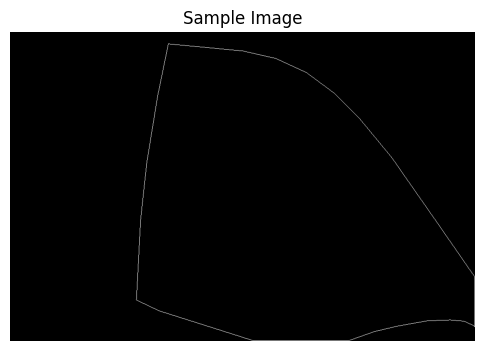

Shape: (665, 1000, 3)
Data type: uint8


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

sample_path = random.choice(all_images)
print("Selected file:", sample_path)

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Sample Image")
plt.axis("off")
plt.show()

print("Shape:", img_rgb.shape)
print("Data type:", img_rgb.dtype)

## EDA and Preprocessing

In [ ]:
base_path = "/content/CarDD_release/CarDD_release/CarDD_SOD"

train_image_dir = os.path.join(base_path, "CarDD-TR", "CarDD-TR-Image")
train_mask_dir  = os.path.join(base_path, "CarDD-TR", "CarDD-TR-Mask")

val_image_dir   = os.path.join(base_path, "CarDD-VAL", "CarDD-VAL-Image")
val_mask_dir    = os.path.join(base_path, "CarDD-VAL", "CarDD-VAL-Mask")

print("Train image dir exists:", os.path.exists(train_image_dir))
print("Train mask dir exists :", os.path.exists(train_mask_dir))
print("Val image dir exists  :", os.path.exists(val_image_dir))
print("Val mask dir exists   :", os.path.exists(val_mask_dir))

Train image dir exists: True
Train mask dir exists : True
Val image dir exists  : True
Val mask dir exists   : True


In [ ]:
from glob import glob

train_images = sorted(glob(os.path.join(train_image_dir, "*.jpg")))
train_masks  = sorted(glob(os.path.join(train_mask_dir, "*.png")))

val_images = sorted(glob(os.path.join(val_image_dir, "*.jpg")))
val_masks  = sorted(glob(os.path.join(val_mask_dir, "*.png")))

print("TRAIN IMAGES:", len(train_images))
print("TRAIN MASKS :", len(train_masks))
print("VAL IMAGES  :", len(val_images))
print("VAL MASKS   :", len(val_masks))

TRAIN IMAGES: 2816
TRAIN MASKS : 2816
VAL IMAGES  : 810
VAL MASKS   : 810


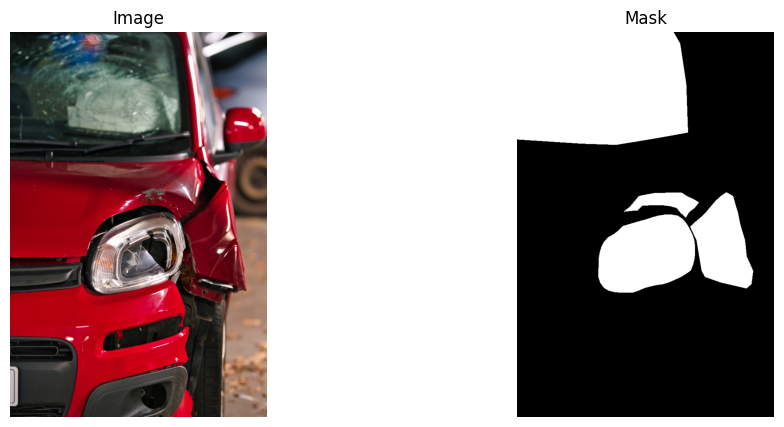

Image shape: (1000, 667, 3)
Mask shape : (1000, 667, 4)
Mask unique values: [  0 255]


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random

idx = random.randint(0, len(train_images)-1)

img = cv2.imread(train_images[idx])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(train_masks[idx], cv2.IMREAD_UNCHANGED)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)
print("Mask unique values:", np.unique(mask))

In [ ]:
import json

coco_json_path = "/content/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_train2017.json"

with open(coco_json_path) as f:
    data = json.load(f)

print("Keys:", data.keys())
print("Number of images:", len(data["images"]))
print("Number of annotations:", len(data["annotations"]))
print("Categories:", data["categories"][:5])
print("Sample annotation:", data["annotations"][0])

Keys: dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])
Number of images: 2816
Number of annotations: 6211
Categories: [{'id': 1, 'name': 'dent'}, {'id': 2, 'name': 'scratch'}, {'id': 3, 'name': 'crack'}, {'id': 4, 'name': 'glass shatter'}, {'id': 5, 'name': 'lamp broken'}]
Sample annotation: {'id': 1, 'image_id': 1, 'category_id': 2, 'segmentation': [[233.35, 46.65, 217.25, 58.24, 210.82, 65.97, 204.38, 78.2, 197.3, 93.0, 192.15, 104.59, 187.0, 112.96, 180.56, 123.91, 174.12, 135.49, 169.61, 144.51, 167.04, 154.16, 167.04, 165.11, 175.41, 170.9, 185.71, 171.55, 196.01, 167.68, 205.02, 161.24, 214.03, 154.81, 224.33, 148.37, 233.99, 141.93, 244.29, 134.21, 256.52, 128.41, 267.47, 125.19, 277.77, 122.62, 288.71, 119.4, 298.37, 116.82, 310.6, 113.61, 322.83, 109.1, 333.13, 105.88, 344.08, 103.95, 355.02, 101.37, 366.61, 97.51, 369.83, 87.21, 364.68, 78.84, 352.45, 69.18, 341.5, 61.46, 331.2, 55.02, 314.46, 48.58, 302.23, 44.72, 291.93, 42.15, 276.48, 40.21, 266.18, 4

In [ ]:
coco_image_dir = "/content/CarDD_release/CarDD_release/CarDD_COCO/train2017"

coco_images = sorted(os.listdir(coco_image_dir))
sod_images  = sorted(os.listdir(train_image_dir))

print("COCO images:", len(coco_images))
print("SOD images :", len(sod_images))

print("First 5 COCO images:", coco_images[:5])
print("First 5 SOD images :", sod_images[:5])

print("Intersection:", len(set(coco_images) & set(sod_images)))

COCO images: 2816
SOD images : 2816
First 5 COCO images: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']
First 5 SOD images : ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']
Intersection: 2816


In [ ]:
import numpy as np
import cv2
import os

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    mask = (mask > 0).astype(np.float32)

    return mask

sample_mask = load_mask(train_masks[0])

print("Mask shape after fix:", sample_mask.shape)
print("Unique values after fix:", np.unique(sample_mask))

Mask shape after fix: (750, 1000)
Unique values after fix: [0. 1.]


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 512

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.5),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from torch.utils.data import Dataset

class CarDamageDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_UNCHANGED)

        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
train_dataset = CarDamageDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = CarDamageDataset(
    val_images,
    val_masks,
    transform=val_transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 2816
Val size: 810


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Image batch shape: torch.Size([4, 3, 512, 512])
Mask batch shape : torch.Size([4, 1, 512, 512])


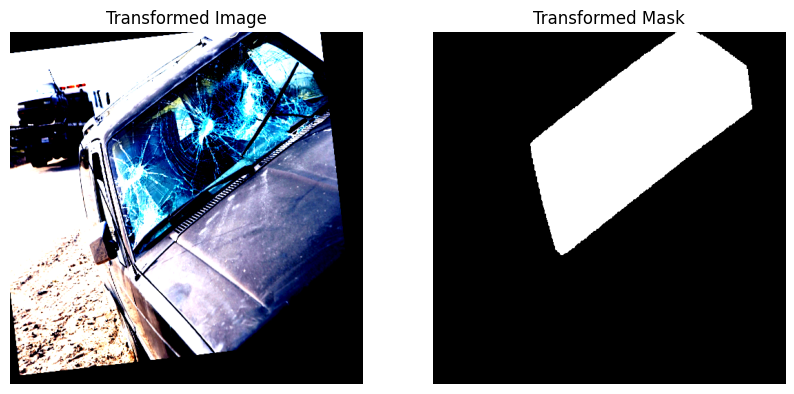

In [ ]:
import torch
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape :", masks.shape)

img = images[0].permute(1,2,0).cpu().numpy()
mask = masks[0][0].cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Transformed Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Transformed Mask")
plt.axis("off")

plt.show()

## Model Building and Training

In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch

model = smp.Unet(
    encoder_name="efficientnet-b0",   # EfficientNet encoder
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(device)

print("U-Net with EfficientNet-B0 encoder created and moved to device.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

U-Net with EfficientNet-B0 encoder created and moved to device.


In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

In [ ]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

    return dice.item()

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

early_stop_patience = 6
epochs_no_improve = 0

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader):
    model.eval()
    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in tqdm(loader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)
            total_loss += loss.item()

            total_dice += dice_score(outputs, masks)

    return total_loss / len(loader), total_dice / len(loader)

In [ ]:
EPOCHS = 50
best_dice = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_dice = validate_one_epoch(model, val_loader)

    scheduler.step(val_dice)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Dice  : {val_dice:.4f}")
    print(f"LR        : {optimizer.param_groups[0]['lr']}")

    if val_dice > best_dice:
        best_dice = val_dice
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved!")

    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered")
        break


Epoch 1/50


100%|██████████| 203/203 [00:23<00:00,  8.50it/s]


Train Loss: 0.8379
Val Loss  : 0.5746
Val Dice  : 0.7501
LR        : 0.0001
Model saved!

Epoch 2/50


100%|██████████| 203/203 [00:22<00:00,  8.86it/s]


Train Loss: 0.6417
Val Loss  : 0.5728
Val Dice  : 0.7333
LR        : 0.0001
No improvement for 1 epochs

Epoch 3/50


...

Train Loss: 0.1929
Val Loss  : 0.3651
Val Dice  : 0.8439
LR        : 1.25e-05
No improvement for 4 epochs

Epoch 45/50


100%|██████████| 203/203 [00:24<00:00,  8.26it/s]


Train Loss: 0.1913
Val Loss  : 0.3603
Val Dice  : 0.8457
LR        : 1.25e-05
No improvement for 5 epochs

Epoch 46/50


100%|██████████| 203/203 [00:24<00:00,  8.23it/s]

Train Loss: 0.1876
Val Loss  : 0.3655
Val Dice  : 0.8440
LR        : 1.25e-05
No improvement for 6 epochs
Early stopping triggered


## Inference

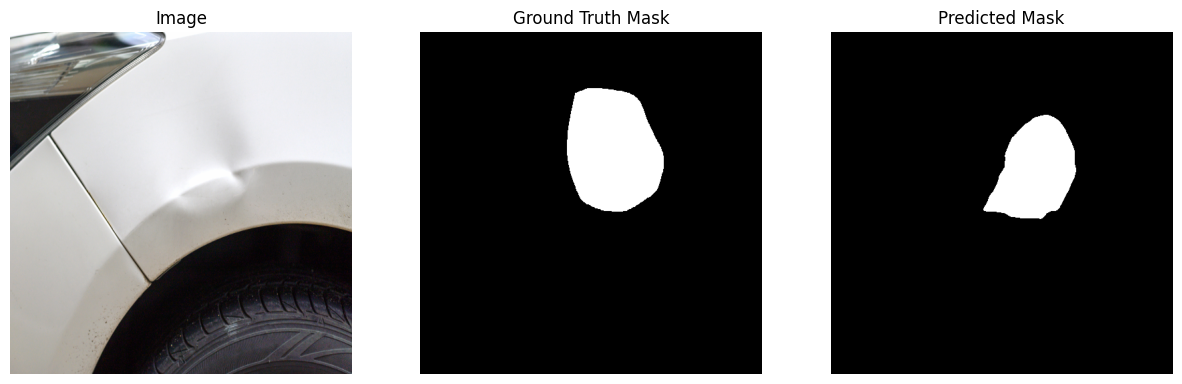

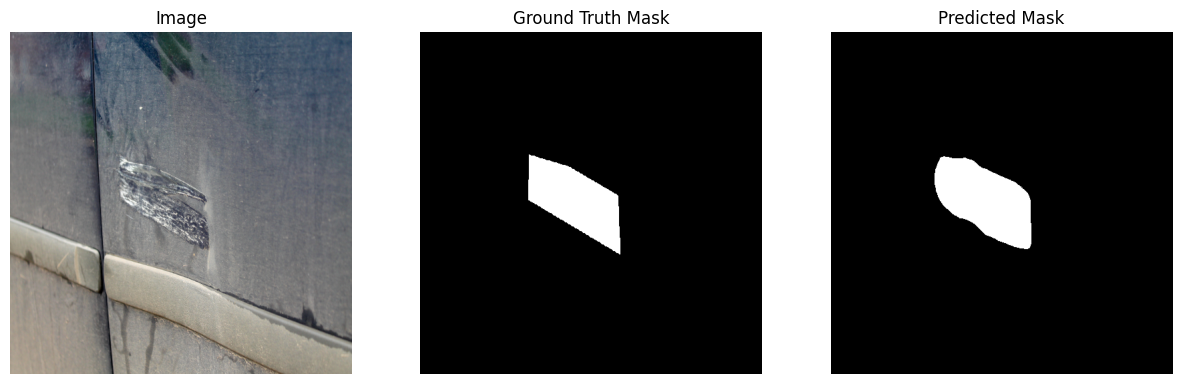

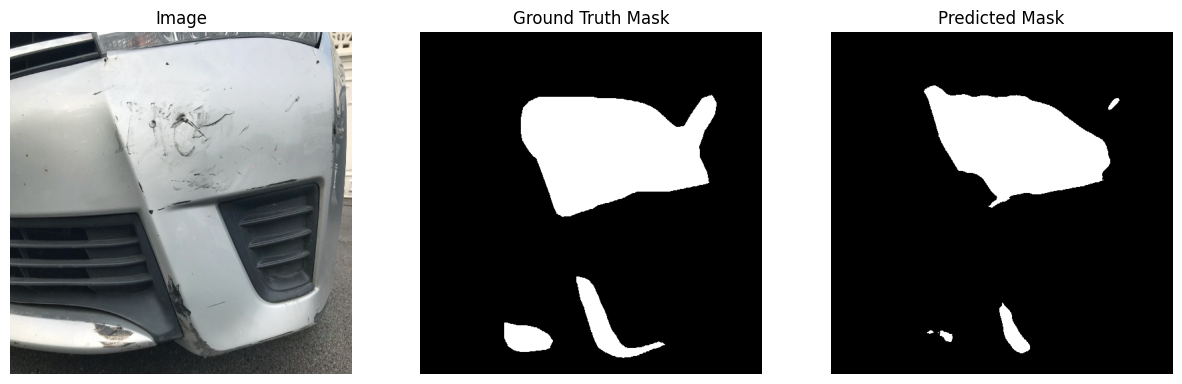

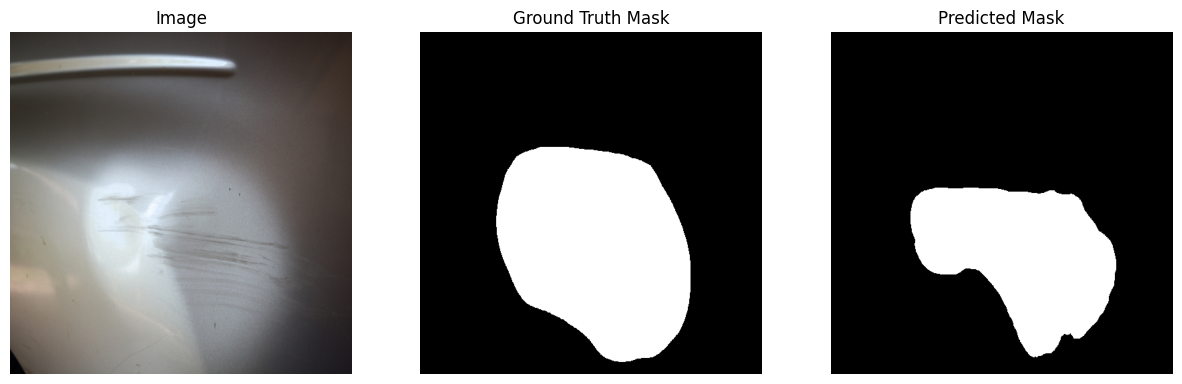

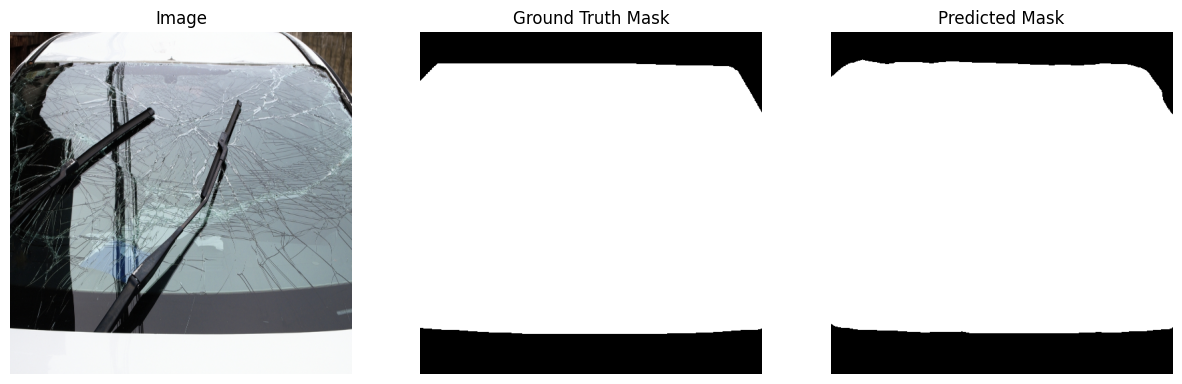

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.load_state_dict(torch.load("/content/best_model.pth", map_location=device))
model.to(device)
model.eval()

num_samples = 5
indices = np.random.choice(len(val_dataset), num_samples, replace=False)

for idx in indices:
    image, mask = val_dataset[idx]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        pred_mask = torch.sigmoid(output).cpu()[0,0].numpy()
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

    img_np = image[0].cpu().permute(1,2,0).numpy()
    img_np = (img_np * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])
    img_np = np.clip(img_np, 0, 1)

    true_mask = mask[0].numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()